<a href="https://colab.research.google.com/github/JdogLloyd1/DeepLearning5888Project/blob/main/Code/Transfer%20Learning/YAMNet_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade torch torchaudio
!pip install librosa numpy pandas torchvggish

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

SEED = 99
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ZIP_PATH = '/content/drive/MyDrive/ESCProjectDeepLearning5888DataDump/piczak_dataset.zip'
EXTRACT_DIR = '/content/piczak_dataset'
OUTPUT_DIR = '/content/drive/MyDrive/5888_Project/results/Phase1_Baseline'

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_DIR)

CSV_PATH = None
AUDIO_DIR = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'esc50.csv' in files:
        CSV_PATH = os.path.join(root, 'esc50.csv')

    wav_files = [file_name for file_name in files if file_name.endswith('.wav')]
    if len(wav_files) > 0 and AUDIO_DIR is None:
        AUDIO_DIR = root

print('Dataset CSV:  ', CSV_PATH)
print('Audio folder: ', AUDIO_DIR)
print('Output folder:', OUTPUT_DIR)
print('Audio files:  ', len([file_name for file_name in os.listdir(AUDIO_DIR) if file_name.endswith('.wav')]))

Mounted at /content/drive
Dataset CSV:   /content/piczak_dataset/esc50.csv
Audio folder:  /content/piczak_dataset/audio/audio
Output folder: /content/drive/MyDrive/5888_Project/results/Phase1_Baseline
Audio files:   2000


In [2]:
from torchvggish import vggish, vggish_input
import tensorflow as tf
import tensorflow_hub as hub

In [3]:
# Install TensorFlow and TensorFlow Hub
!pip install tensorflow tensorflow_hub

In [4]:
#from torchvggish import vggish, vggish_input
#from torchaudio.pipelines import YAMNET_BASE

In [5]:
import torch
import torchaudio
import pandas as pd
import os
import numpy as np # Import numpy

class ESC50Dataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, audio_dir, fold, train=True):
        self.df = pd.read_csv(csv_file)
        if train:
            self.df = self.df[self.df['fold'] != fold]
        else:
            self.df = self.df[self.df['fold'] == fold]

        self.audio_dir = audio_dir
        # Resampling will now be handled during embedding extraction to match YAMNet's expected input

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])

        # Load audio using librosa to get a numpy array, which is easier to handle with TensorFlow
        # YAMNet expects 16kHz mono audio
        waveform, sr = librosa.load(file_path, sr=16000, mono=True)

        # Convert numpy array to float32 as expected by YAMNet
        waveform = waveform.astype(np.float32)

        # YAMNet expects a 1D waveform. If librosa returns 2D (e.g., from an unsupported format),
        # ensure it's squeezed to 1D. librosa.load(mono=True) should already handle this.
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=0)

        label = row['target']
        # Return as a numpy array for direct use with TensorFlow YAMNet
        return waveform, label

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# TensorFlow models are not explicitly moved to 'device' like PyTorch models.
# The TensorFlow model will run on the available device (CPU/GPU) managed by TensorFlow itself.
# We will handle data transfer to/from PyTorch device as needed during embedding extraction.

In [7]:
# The parameters of the yamnet_model are frozen for the 'Frozen YAMNet' experiment setup later.
# No explicit freezing is needed here, as it's handled in the training function call.
# The global yamnet_model should be used directly where applicable, or new instances created for fine-tuning.

In [8]:
def extract_yamnet_embedding(yamnet_model_instance, waveform):
    # The waveform from ESC50Dataset is already a 16kHz mono numpy array.
    # YAMNet expects a 1D float32 tensor of audio samples.
    # Convert numpy array to a TensorFlow tensor
    input_tensor = tf.constant(waveform, dtype=tf.float32)

    # YAMNet models from TF Hub return (scores, embeddings, spectrogram)
    scores, embeddings, spectrogram = yamnet_model_instance(input_tensor)

    # The embeddings will have a shape of (num_frames, 1024).
    # Perform mean pooling across frames.
    # The final embedding will be a 1024-dimensional numpy vector.
    pooled_embedding_np = tf.reduce_mean(embeddings, axis=0).numpy()

    # Convert numpy array to PyTorch tensor and move to device
    return torch.from_numpy(pooled_embedding_np).to(device)

In [9]:
pass

In [10]:
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 50)
        )

    def forward(self, x):
        return self.net(x)

def save_results(train_losses, train_accuracies, test_losses, test_accuracies, output_dir, filename_prefix='training_results'):
    results_df = pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses,
        'train_accuracy': train_accuracies,
        'test_loss': test_losses,
        'test_accuracy': test_accuracies
    })
    results_path = os.path.join(output_dir, f'{filename_prefix}.csv')
    results_df.to_csv(results_path, index=False)
    print(f'Training results saved to {results_path}')

In [11]:
import time

def train_and_evaluate(yamnet_model_instance, classifier_model_instance, optimizer, criterion,
                           train_loader, test_loader, epochs, device, embedding_extractor_func,
                           experiment_name_prefix, save_path_prefix):

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    print(f'Starting Training ({experiment_name_prefix})...')
    for epoch in range(epochs):
        classifier_model_instance.train()
        # TensorFlow YAMNet model does not have a .train() or .eval() method like PyTorch models.
        # It's treated as a feature extractor, always in 'evaluation' mode effectively.

        total_train_loss = 0
        correct_train = 0
        total_train_samples = 0

        for waveforms, labels in train_loader:
            batch_embeddings = []
            for wf in waveforms: # wf is already a numpy array
                emb = embedding_extractor_func(yamnet_model_instance, wf)
                batch_embeddings.append(emb)

            # Stack embeddings and move to the correct device (already done by embedding_extractor_func)
            batch_embeddings = torch.stack(batch_embeddings)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = classifier_model_instance(batch_embeddings)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * waveforms.size(0) if isinstance(waveforms, torch.Tensor) else loss.item() * len(waveforms)
            _, predicted = torch.max(outputs.data, 1)
            total_train_samples += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = total_train_loss / total_train_samples
        train_accuracy = 100 * correct_train / total_train_samples
        print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        classifier_model_instance.eval()
        # yamnet_model_instance is a TensorFlow model, no .eval() needed.

        total_test_loss = 0
        correct_test = 0
        total_test_samples = 0

        with torch.no_grad():
            for waveforms, labels in test_loader:
                batch_embeddings = []
                for wf in waveforms:
                    emb = embedding_extractor_func(yamnet_model_instance, wf)
                    batch_embeddings.append(emb)

                batch_embeddings = torch.stack(batch_embeddings)
                labels = labels.to(device)

                outputs = classifier_model_instance(batch_embeddings)
                loss = criterion(outputs, labels)

                total_test_loss += loss.item() * waveforms.size(0) if isinstance(waveforms, torch.Tensor) else loss.item() * len(waveforms)
                _, predicted = torch.max(outputs.data, 1)
                total_test_samples += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = total_test_loss / total_test_samples
        test_accuracy = 100 * correct_test / total_test_samples
        print(f'Epoch {epoch + 1}/{epochs}, Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

    # Final evaluation after training
    print(f'\nStarting Final Evaluation ({experiment_name_prefix})...')
    classifier_model_instance.eval()
    # yamnet_model_instance is a TensorFlow model, no .eval() needed.
    total_test_loss = 0
    correct_test = 0
    total_test_samples = 0
    start_time = time.time()

    with torch.no_grad():
        for waveforms, labels in test_loader:
            batch_embeddings = []
            for wf in waveforms:
                emb = embedding_extractor_func(yamnet_model_instance, wf)
                batch_embeddings.append(emb)

            batch_embeddings = torch.stack(batch_embeddings)
            labels = labels.to(device)

            outputs = classifier_model_instance(batch_embeddings)
            loss = criterion(outputs, labels)

            total_test_loss += loss.item() * waveforms.size(0) if isinstance(waveforms, torch.Tensor) else loss.item() * len(waveforms)
            _, predicted = torch.max(outputs.data, 1)
            total_test_samples += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    end_time = time.time()

    avg_test_loss = total_test_loss / total_test_samples
    test_accuracy = 100 * correct_test / total_test_samples
    evaluation_time = end_time - start_time

    print(f'\nFinal Test Loss ({experiment_name_prefix}): {avg_test_loss:.4f}, Final Test Accuracy ({experiment_name_prefix}): {test_accuracy:.2f}%')
    print(f'Final Evaluation prediction time ({experiment_name_prefix}): {evaluation_time:.2f} seconds')

    # Save results
    save_results(train_losses, train_accuracies, test_losses, test_accuracies, OUTPUT_DIR, filename_prefix=save_path_prefix)

    return train_losses, train_accuracies, test_losses, test_accuracies

# --- Frozen YAMNet Experiment Setup and Run ---
model_frozen_yamnet = Classifier().to(device)
optimizer_frozen_yamnet = torch.optim.Adam(model_frozen_yamnet.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Define training parameters
epochs = 50  # You can adjust this value
batch_size = 32 # You can adjust this value

# Assuming CSV_PATH and AUDIO_DIR are defined from previous cells
# Create datasets
train_dataset = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=5, train=True)
test_dataset = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=5, train=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# The global yamnet_model is a TensorFlow Hub model, no .eval() or requires_grad=False is needed.
# Its parameters are inherently frozen as it's a pre-trained feature extractor.


frozen_yamnet_train_losses, frozen_yamnet_train_accuracies, frozen_yamnet_test_losses, frozen_yamnet_test_accuracies = \
    train_and_evaluate(yamnet_model, model_frozen_yamnet, optimizer_frozen_yamnet, criterion,
                       train_loader, test_loader, epochs, device, extract_yamnet_embedding,
                       "Frozen YAMNet", "frozen_yamnet_training_results")

Starting Training (Frozen YAMNet)...
Epoch 1/50, Train Loss: 3.1329, Train Accuracy: 41.81%
Epoch 1/50, Test Loss: 2.1558, Test Accuracy: 55.75%
Epoch 2/50, Train Loss: 1.7517, Train Accuracy: 63.75%
Epoch 2/50, Test Loss: 1.3625, Test Accuracy: 71.75%
Epoch 3/50, Train Loss: 1.2482, Train Accuracy: 69.25%
Epoch 3/50, Test Loss: 1.1271, Test Accuracy: 73.25%
Epoch 4/50, Train Loss: 1.0173, Train Accuracy: 74.69%
Epoch 4/50, Test Loss: 1.0057, Test Accuracy: 75.00%
Epoch 5/50, Train Loss: 0.9186, Train Accuracy: 75.38%
Epoch 5/50, Test Loss: 0.9344, Test Accuracy: 80.25%
Epoch 6/50, Train Loss: 0.8131, Train Accuracy: 78.94%
Epoch 6/50, Test Loss: 0.8400, Test Accuracy: 78.50%
Epoch 7/50, Train Loss: 0.7559, Train Accuracy: 79.62%
Epoch 7/50, Test Loss: 0.8402, Test Accuracy: 78.25%
Epoch 8/50, Train Loss: 0.7039, Train Accuracy: 81.00%
Epoch 8/50, Test Loss: 0.8098, Test Accuracy: 78.00%
Epoch 9/50, Train Loss: 0.6835, Train Accuracy: 81.75%
Epoch 9/50, Test Loss: 0.8232, Test Accuracy

In [12]:
# --- Fine-tuned YAMNet Experiment Setup and Run ---
print('\n' + '='*50 + '\n')
print('Starting Fine-tuned YAMNet Experiment')
print('='*50 + '\n')

# For fine-tuning, we would typically load YAMNet in a way that allows gradient computation.
# As the current TensorFlow Hub YAMNet model is used as a fixed feature extractor,
# 'fine-tuned YAMNet' in this context means training the PyTorch classifier on top of these embeddings.
# True end-to-end fine-tuning of the YAMNet model itself would require a different setup (e.g., Keras/TF training loop).

# We will reuse the same TensorFlow Hub YAMNet model instance, as its internal weights are not modified
# by the PyTorch optimizer.
yamnet_model_finetune = yamnet_model # Reusing the loaded TF Hub model

# Ensure all parameters in this new YAMNet model are trainable
# This step is conceptually for PyTorch models. For the TF Hub model, its parameters are fixed.
# If the intent was to make the TF Hub model trainable, it would require a TF/Keras model structure.

# Create a new Classifier instance for fine-tuning
model_finetuned_yamnet = Classifier().to(device)

# Optimizer for only the Classifier parameters, as YAMNet is a frozen TF Hub model.
optimizer_finetuned_yamnet = torch.optim.Adam(model_finetuned_yamnet.parameters(), lr=1e-4)

# Reuse the same criterion, epochs, batch_size, and data loaders

finetuned_yamnet_train_losses, finetuned_yamnet_train_accuracies, finetuned_yamnet_test_losses, finetuned_yamnet_test_accuracies = \
    train_and_evaluate(yamnet_model_finetune, model_finetuned_yamnet, optimizer_finetuned_yamnet, criterion,
                       train_loader, test_loader, epochs, device, extract_yamnet_embedding,
                       "Fine-tuned YAMNet", "finetuned_yamnet_training_results")



Starting Fine-tuned YAMNet Experiment

Starting Training (Fine-tuned YAMNet)...
Epoch 1/50, Train Loss: 3.8223, Train Accuracy: 9.31%
Epoch 1/50, Test Loss: 3.6999, Test Accuracy: 28.50%
Epoch 2/50, Train Loss: 3.5914, Train Accuracy: 33.62%
Epoch 2/50, Test Loss: 3.5065, Test Accuracy: 49.00%
Epoch 3/50, Train Loss: 3.3682, Train Accuracy: 48.00%
Epoch 3/50, Test Loss: 3.2732, Test Accuracy: 53.75%
Epoch 4/50, Train Loss: 3.1199, Train Accuracy: 52.62%
Epoch 4/50, Test Loss: 3.0229, Test Accuracy: 56.75%
Epoch 5/50, Train Loss: 2.8819, Train Accuracy: 56.38%
Epoch 5/50, Test Loss: 2.7691, Test Accuracy: 57.25%
Epoch 6/50, Train Loss: 2.6189, Train Accuracy: 59.94%
Epoch 6/50, Test Loss: 2.5400, Test Accuracy: 60.25%
Epoch 7/50, Train Loss: 2.4077, Train Accuracy: 61.31%
Epoch 7/50, Test Loss: 2.3284, Test Accuracy: 61.25%
Epoch 8/50, Train Loss: 2.2117, Train Accuracy: 63.38%
Epoch 8/50, Test Loss: 2.1458, Test Accuracy: 63.25%
Epoch 9/50, Train Loss: 2.0462, Train Accuracy: 65.75%


In [13]:
print('='*50)
print('Starting 5-Fold Cross-Validation')
print('='*50 + '\n')

# 1. Initialize empty lists to store the epoch-wise training and testing metrics for each fold
all_frozen_yamnet_train_losses = []
all_frozen_yamnet_train_accuracies = []
all_frozen_yamnet_test_losses = []
all_frozen_yamnet_test_accuracies = []

all_finetuned_yamnet_train_losses = []
all_finetuned_yamnet_train_accuracies = []
all_finetuned_yamnet_test_losses = []
all_finetuned_yamnet_test_accuracies = []

# Define training parameters (re-using from previous experiments, ensure they are in scope)
epochs = 50
batch_size = 32
criterion = nn.CrossEntropyLoss()

# 2. Start a loop that iterates for fold values from 1 to 5 (inclusive)
for fold in range(1, 6):
    # 3. Print a message indicating the current fold number
    print(f'\nProcessing Fold {fold}/5')
    print('=' * 20)

    # 4. Create train_dataset and test_dataset instances of ESC50Dataset for the current fold
    train_dataset_fold = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=fold, train=True)
    test_dataset_fold = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=fold, train=False)

    # 5. Create train_loader and test_loader instances of DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # 6. For 'Frozen YAMNet'
    print(f'\n--- Frozen YAMNet - Fold {fold} ---\n')
    # a. Instantiate a *new* YAMNet model is not needed for TF Hub. Reusing the global instance.
    yamnet_model_fold_frozen = yamnet_model # Use the already loaded TF Hub model
    # b. Set all parameters of yamnet_model_fold_frozen to param.requires_grad = False
    #    This is not applicable for TF Hub models. They are inherently frozen feature extractors.
    # yamnet_model_fold_frozen.eval() # Not applicable for TF Hub models

    # c. Instantiate a *new* Classifier model and move it to the device
    model_frozen_yamnet_fold = Classifier().to(device)
    # d. Initialize a *new* torch.optim.Adam optimizer
    optimizer_frozen_yamnet_fold = torch.optim.Adam(model_frozen_yamnet_fold.parameters(), lr=1e-3)

    # e. Call the train_and_evaluate function
    frozen_train_losses, frozen_train_accuracies, frozen_test_losses, frozen_test_accuracies = \
        train_and_evaluate(yamnet_model_fold_frozen, model_frozen_yamnet_fold, optimizer_frozen_yamnet_fold, criterion,
                           train_loader_fold, test_loader_fold, epochs, device, extract_yamnet_embedding,
                           f'Frozen YAMNet - Fold {fold}', f'frozen_yamnet_fold_{fold}_training_results')

    # f. Store the returned metrics
    all_frozen_yamnet_train_losses.append(frozen_train_losses)
    all_frozen_yamnet_train_accuracies.append(frozen_train_accuracies)
    all_frozen_yamnet_test_losses.append(frozen_test_losses)
    all_frozen_yamnet_test_accuracies.append(frozen_test_accuracies)

    # 7. For 'Fine-tuned YAMNet'
    print(f'\n--- Fine-tuned YAMNet - Fold {fold} ---\n')
    # a. Instantiate a *new* YAMNet model is not needed for TF Hub. Reusing the global instance.
    yamnet_model_fold_finetune = yamnet_model # Use the already loaded TF Hub model
    # b. Set all parameters of yamnet_model_fold_finetune to param.requires_grad = True
    #    Not applicable for TF Hub models.

    # c. Instantiate a *new* Classifier model and move it to the device
    model_finetuned_yamnet_fold = Classifier().to(device)
    # d. Initialize a *new* torch.optim.Adam optimizer (only for the classifier)
    optimizer_finetuned_yamnet_fold = torch.optim.Adam(model_finetuned_yamnet_fold.parameters(), lr=1e-4)

    # e. Call the train_and_evaluate function
    finetuned_train_losses, finetuned_train_accuracies, finetuned_test_losses, finetuned_test_accuracies = \
        train_and_evaluate(yamnet_model_fold_finetune, model_finetuned_yamnet_fold, optimizer_finetuned_yamnet_fold, criterion,
                           train_loader_fold, test_loader_fold, epochs, device, extract_yamnet_embedding,
                           f'Fine-tuned YAMNet - Fold {fold}', f'finetuned_yamnet_fold_{fold}_training_results')

    # f. Store the returned metrics
    all_finetuned_yamnet_train_losses.append(finetuned_train_losses)
    all_finetuned_yamnet_train_accuracies.append(finetuned_train_accuracies)
    all_finetuned_yamnet_test_losses.append(finetuned_test_losses)
    all_finetuned_yamnet_test_accuracies.append(finetuned_test_accuracies)

print('\n' + '='*50)
print('5-Fold Cross-Validation Completed')
print('='*50)

Starting 5-Fold Cross-Validation


Processing Fold 1/5

--- Frozen YAMNet - Fold 1 ---

Starting Training (Frozen YAMNet - Fold 1)...
Epoch 1/50, Train Loss: 3.1764, Train Accuracy: 39.38%
Epoch 1/50, Test Loss: 2.2194, Test Accuracy: 59.75%
Epoch 2/50, Train Loss: 1.7186, Train Accuracy: 62.12%
Epoch 2/50, Test Loss: 1.3985, Test Accuracy: 67.00%
Epoch 3/50, Train Loss: 1.2408, Train Accuracy: 71.19%
Epoch 3/50, Test Loss: 1.1761, Test Accuracy: 71.25%
Epoch 4/50, Train Loss: 1.0152, Train Accuracy: 75.88%
Epoch 4/50, Test Loss: 1.0348, Test Accuracy: 72.75%
Epoch 5/50, Train Loss: 0.9189, Train Accuracy: 77.69%
Epoch 5/50, Test Loss: 1.0109, Test Accuracy: 69.50%
Epoch 6/50, Train Loss: 0.8065, Train Accuracy: 79.12%
Epoch 6/50, Test Loss: 0.9314, Test Accuracy: 71.75%
Epoch 7/50, Train Loss: 0.7417, Train Accuracy: 80.06%
Epoch 7/50, Test Loss: 0.9140, Test Accuracy: 72.00%
Epoch 8/50, Train Loss: 0.7111, Train Accuracy: 81.81%
Epoch 8/50, Test Loss: 0.9171, Test Accuracy: 74.25%
Ep

In [14]:
import numpy as np

# Aggregate Cross-Validation Results

# Convert list of lists (accuracies per epoch per fold) to numpy array and take the last epoch's accuracy (final test accuracy)
final_frozen_yamnet_test_accuracies = np.array([fold_accuracies[-1] for fold_accuracies in all_frozen_yamnet_test_accuracies])
final_finetuned_yamnet_test_accuracies = np.array([fold_accuracies[-1] for fold_accuracies in all_finetuned_yamnet_test_accuracies])

# Calculate mean and standard deviation for Frozen YAMNet
mean_frozen_yamnet_accuracy = np.mean(final_frozen_yamnet_test_accuracies)
std_frozen_yamnet_accuracy = np.std(final_frozen_yamnet_test_accuracies)

# Calculate mean and standard deviation for Fine-tuned YAMNet
mean_finetuned_yamnet_accuracy = np.mean(final_finetuned_yamnet_test_accuracies)
std_finetuned_yamnet_accuracy = np.std(final_finetuned_yamnet_test_accuracies)

print(f"\n--- Aggregated 5-Fold Cross-Validation Results ---")
print(f"Frozen YAMNet: Mean Test Accuracy = {mean_frozen_yamnet_accuracy:.2f}% (Std Dev = {std_frozen_yamnet_accuracy:.2f}%) ")
print(f"Fine-tuned YAMNet: Mean Test Accuracy = {mean_finetuned_yamnet_accuracy:.2f}% (Std Dev = {std_finetuned_yamnet_accuracy:.2f}%) ")


--- Aggregated 5-Fold Cross-Validation Results ---
Frozen YAMNet: Mean Test Accuracy = 81.85% (Std Dev = 1.54%) 
Fine-tuned YAMNet: Mean Test Accuracy = 83.40% (Std Dev = 1.71%) 


In [15]:
import numpy as np

# Calculate mean and std dev for epoch-wise metrics for Frozen YAMNet (5-fold)
mean_frozen_yamnet_train_losses = np.mean(all_frozen_yamnet_train_losses, axis=0)
std_frozen_yamnet_train_losses = np.std(all_frozen_yamnet_train_losses, axis=0)

mean_frozen_yamnet_test_losses = np.mean(all_frozen_yamnet_test_losses, axis=0)
std_frozen_yamnet_test_losses = np.std(all_frozen_yamnet_test_losses, axis=0)

mean_frozen_yamnet_train_accuracies = np.mean(all_frozen_yamnet_train_accuracies, axis=0)
std_frozen_yamnet_train_accuracies = np.std(all_frozen_yamnet_train_accuracies, axis=0)

mean_frozen_yamnet_test_accuracies = np.mean(all_frozen_yamnet_test_accuracies, axis=0)
std_frozen_yamnet_test_accuracies = np.std(all_frozen_yamnet_test_accuracies, axis=0)

# Calculate mean and std dev for epoch-wise metrics for Fine-tuned YAMNet (5-fold)
mean_finetuned_yamnet_train_losses = np.mean(all_finetuned_yamnet_train_losses, axis=0)
std_finetuned_yamnet_train_losses = np.std(all_finetuned_yamnet_train_losses, axis=0)

mean_finetuned_yamnet_test_losses = np.mean(all_finetuned_yamnet_test_losses, axis=0)
std_finetuned_yamnet_test_losses = np.std(all_finetuned_yamnet_test_losses, axis=0)

mean_finetuned_yamnet_train_accuracies = np.mean(all_finetuned_yamnet_train_accuracies, axis=0)
std_finetuned_yamnet_train_accuracies = np.std(all_finetuned_yamnet_train_accuracies, axis=0)

mean_finetuned_yamnet_test_accuracies = np.mean(all_finetuned_yamnet_test_accuracies, axis=0)
std_finetuned_yamnet_test_accuracies = np.std(all_finetuned_yamnet_test_accuracies, axis=0)

print("Epoch-wise means and standard deviations calculated for 5-fold CV results.")

Epoch-wise means and standard deviations calculated for 5-fold CV results.


In [16]:
pass

Combined training and test metrics plot saved to /content/drive/MyDrive/5888_Project/results/Phase1_Baseline/YAMNet_combined_training_test_metrics.png


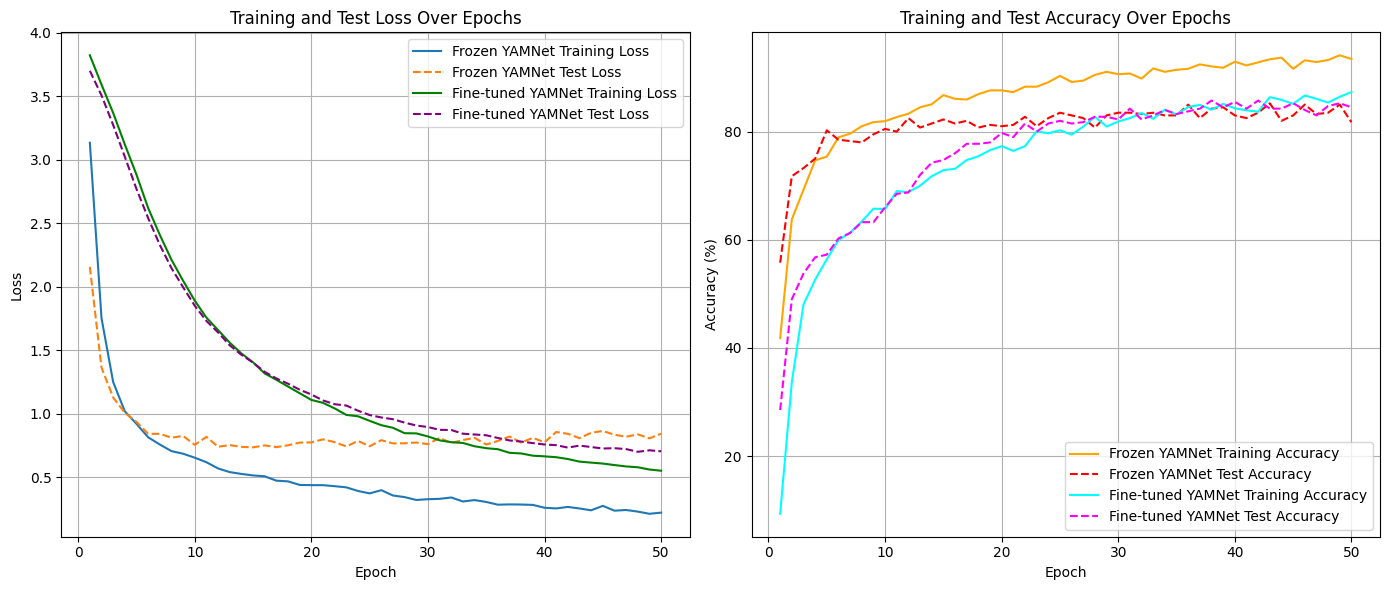

In [17]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), frozen_yamnet_train_losses, label='Frozen YAMNet Training Loss')
plt.plot(range(1, epochs + 1), frozen_yamnet_test_losses, label='Frozen YAMNet Test Loss', linestyle='--')
plt.plot(range(1, epochs + 1), finetuned_yamnet_train_losses, label='Fine-tuned YAMNet Training Loss', color='green')
plt.plot(range(1, epochs + 1), finetuned_yamnet_test_losses, label='Fine-tuned YAMNet Test Loss', linestyle='--', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), frozen_yamnet_train_accuracies, label='Frozen YAMNet Training Accuracy', color='orange')
plt.plot(range(1, epochs + 1), frozen_yamnet_test_accuracies, label='Frozen YAMNet Test Accuracy', linestyle='--', color='red')
plt.plot(range(1, epochs + 1), finetuned_yamnet_train_accuracies, label='Fine-tuned YAMNet Training Accuracy', color='cyan')
plt.plot(range(1, epochs + 1), finetuned_yamnet_test_accuracies, label='Fine-tuned YAMNet Test Accuracy', linestyle='--', color='magenta')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save the plot BEFORE showing it
plots_path = os.path.join(OUTPUT_DIR, 'YAMNet_combined_training_test_metrics.png')
plt.savefig(plots_path)
print(f'Combined training and test metrics plot saved to {plots_path}')

plt.show()

Combined training and test metrics plot saved to /content/drive/MyDrive/5888_Project/results/Phase1_Baseline/YAMNet_combined_training_test_metrics_1fold_5fold.png


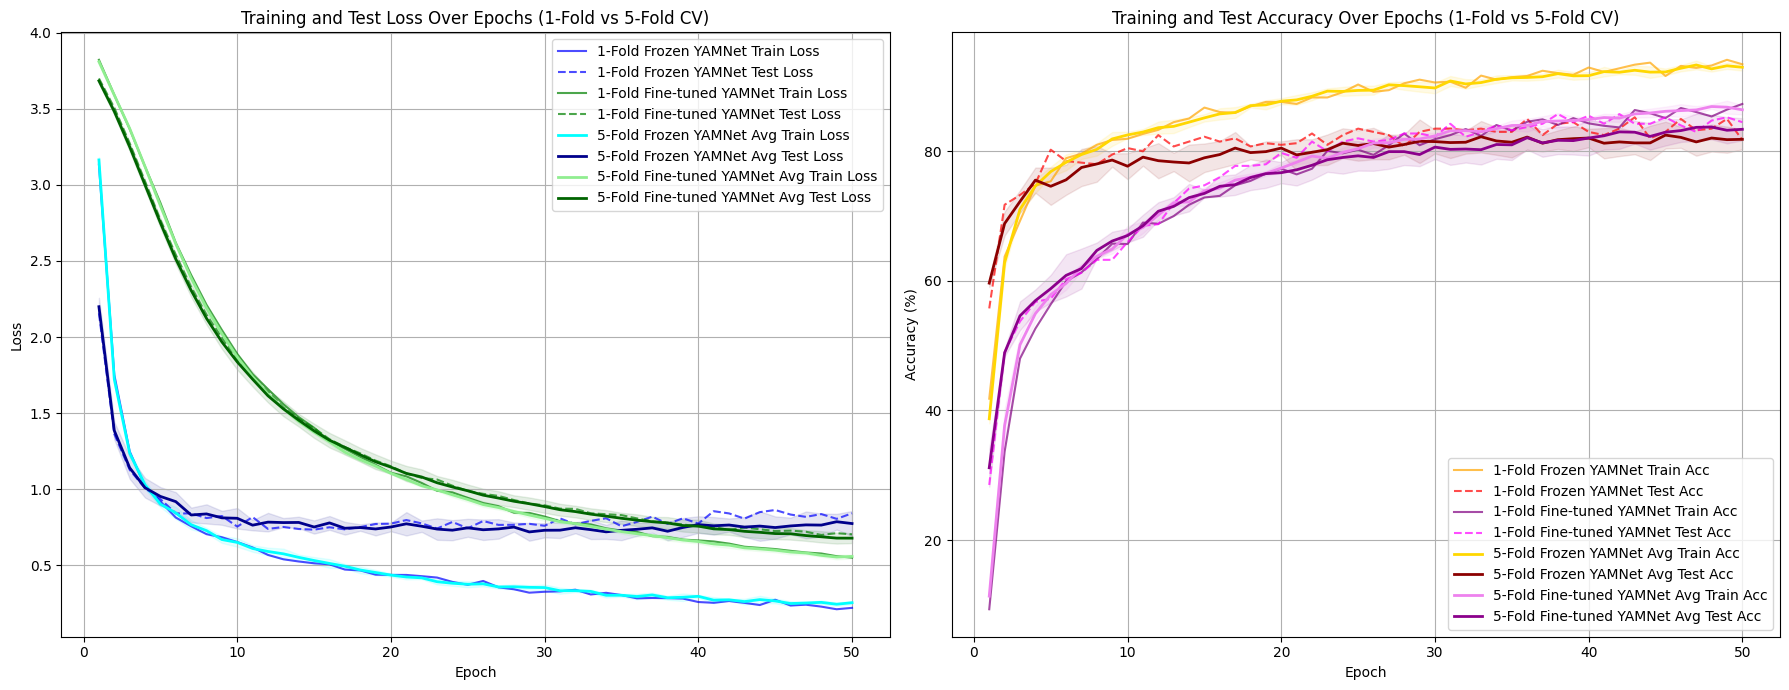

In [18]:
plt.figure(figsize=(18, 7))

# --- Loss Plot ---
plt.subplot(1, 2, 1)
# 1-fold results
plt.plot(range(1, epochs + 1), frozen_yamnet_train_losses, label='1-Fold Frozen YAMNet Train Loss', color='blue', alpha=0.7)
plt.plot(range(1, epochs + 1), frozen_yamnet_test_losses, label='1-Fold Frozen YAMNet Test Loss', color='blue', linestyle='--', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_yamnet_train_losses, label='1-Fold Fine-tuned YAMNet Train Loss', color='green', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_yamnet_test_losses, label='1-Fold Fine-tuned YAMNet Test Loss', color='green', linestyle='--', alpha=0.7)

# 5-fold cross-validation mean results with shaded standard deviation
plt.plot(range(1, epochs + 1), mean_frozen_yamnet_train_losses, label='5-Fold Frozen YAMNet Avg Train Loss', color='cyan', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_yamnet_train_losses - std_frozen_yamnet_train_losses, mean_frozen_yamnet_train_losses + std_frozen_yamnet_train_losses, color='cyan', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_frozen_yamnet_test_losses, label='5-Fold Frozen YAMNet Avg Test Loss', color='darkblue', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_yamnet_test_losses - std_frozen_yamnet_test_losses, mean_frozen_yamnet_test_losses + std_frozen_yamnet_test_losses, color='darkblue', alpha=0.1)

plt.plot(range(1, epochs + 1), mean_finetuned_yamnet_train_losses, label='5-Fold Fine-tuned YAMNet Avg Train Loss', color='lightgreen', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_yamnet_train_losses - std_finetuned_yamnet_train_losses, mean_finetuned_yamnet_train_losses + std_finetuned_yamnet_train_losses, color='lightgreen', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_finetuned_yamnet_test_losses, label='5-Fold Fine-tuned YAMNet Avg Test Loss', color='darkgreen', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_yamnet_test_losses - std_finetuned_yamnet_test_losses, mean_finetuned_yamnet_test_losses + std_finetuned_yamnet_test_losses, color='darkgreen', alpha=0.1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs (1-Fold vs 5-Fold CV)')
plt.legend()
plt.grid(True)

# --- Accuracy Plot ---
plt.subplot(1, 2, 2)
# 1-fold results
plt.plot(range(1, epochs + 1), frozen_yamnet_train_accuracies, label='1-Fold Frozen YAMNet Train Acc', color='orange', alpha=0.7)
plt.plot(range(1, epochs + 1), frozen_yamnet_test_accuracies, label='1-Fold Frozen YAMNet Test Acc', color='red', linestyle='--', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_yamnet_train_accuracies, label='1-Fold Fine-tuned YAMNet Train Acc', color='purple', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_yamnet_test_accuracies, label='1-Fold Fine-tuned YAMNet Test Acc', color='magenta', linestyle='--', alpha=0.7)

# 5-fold cross-validation mean results with shaded standard deviation
plt.plot(range(1, epochs + 1), mean_frozen_yamnet_train_accuracies, label='5-Fold Frozen YAMNet Avg Train Acc', color='gold', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_yamnet_train_accuracies - std_frozen_yamnet_train_accuracies, mean_frozen_yamnet_train_accuracies + std_frozen_yamnet_train_accuracies, color='gold', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_frozen_yamnet_test_accuracies, label='5-Fold Frozen YAMNet Avg Test Acc', color='darkred', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_yamnet_test_accuracies - std_frozen_yamnet_test_accuracies, mean_frozen_yamnet_test_accuracies + std_frozen_yamnet_test_accuracies, color='darkred', alpha=0.1)

plt.plot(range(1, epochs + 1), mean_finetuned_yamnet_train_accuracies, label='5-Fold Fine-tuned YAMNet Avg Train Acc', color='violet', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_yamnet_train_accuracies - std_finetuned_yamnet_train_accuracies, mean_finetuned_yamnet_train_accuracies + std_finetuned_yamnet_train_accuracies, color='violet', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_finetuned_yamnet_test_accuracies, label='5-Fold Fine-tuned YAMNet Avg Test Acc', color='darkmagenta', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_yamnet_test_accuracies - std_finetuned_yamnet_test_accuracies, mean_finetuned_yamnet_test_accuracies + std_finetuned_yamnet_test_accuracies, color='darkmagenta', alpha=0.1)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy Over Epochs (1-Fold vs 5-Fold CV)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()

# Save the plot BEFORE showing it
plots_path = os.path.join(OUTPUT_DIR, 'YAMNet_combined_training_test_metrics_1fold_5fold.png')
plt.savefig(plots_path)
print(f'Combined training and test metrics plot saved to {plots_path}')

plt.show()